In [1]:
import cmdstanpy
cmdstanpy.install_cmdstan()

/media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CmdStan install directory: /home/brasammy/.cmdstan
CmdStan version 2.36.0 already installed
Test model compilation


True

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

import logging
logging.getLogger("cmdstanpy").setLevel(logging.INFO)
from scipy.integrate import odeint

Imputation Done!!!


In [3]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    S, E, I, R = state
    dS = -beta * S * I / N
    dE =  beta * S * I / N - sigma * E
    dI =  sigma * E - gamma * I
    dR =  gamma * I
    return [dS, dE, dI, dR]


In [4]:
# Parameters
n_regions = 3  # Guinea, Liberia, Sierra Leone
T = 450  # Time points (days)
N = [11.5e6, 4.5e6, 6.8e6]  # Population per region
beta = [0.3, 0.4, 0.35]  # Transmission rate (R0 = beta/gamma)
sigma = 1/7  # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/5  # 1/infectious period (Ebola: ~7 days)
phi = 10.0  # Negative binomial dispersion parameter
reporting_rate = 0.8  # Proportion of cases reported

# Initial conditions
guinea = [N[0]-10, 0, 10, 0]
lib = [N[1]-20, 0, 20, 0]
sir = [N[2]-10, 0, 10, 0]

initial_state = [guinea, lib, sir]

# Time vector
t = np.linspace(0, T-1, T)

In [5]:
initial_state

[[11499990.0, 0, 10, 0], [4499980.0, 0, 20, 0], [6799990.0, 0, 10, 0]]

In [6]:
# Simulate SEIR for each region
states = np.zeros((n_regions, T, 4))
incidence = np.zeros((n_regions, T))

for i in range(n_regions):
    # Solve ODE
    sol = odeint(seir, initial_state[i], t, args=(beta[i], sigma, gamma, N[i]))
    states[i] = sol
    # Incidence = new infections = beta * S * I / N
    incidence[i] = beta[i] * sol[:, 0] * sol[:, 2] / N[i]

In [7]:
# Generate observed cases using negative binomial
observed_cases = np.zeros((n_regions, T), dtype=int)
for i in range(n_regions):
    for t in range(T):
        mean_cases = reporting_rate * incidence[i, t]
        # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
        p = phi / (phi + mean_cases)
        r = phi
        observed_cases[i, t] = np.random.negative_binomial(r, p)


In [8]:
# Save data to CSV
# Time vector
t = np.linspace(0, T-1, T)
data = {
    'time': np.tile(t, n_regions),
    'country': np.repeat(['Guinea', 'Liberia', 'Sierra Leone'], T),
    'cases': observed_cases.flatten()
}
df = pd.DataFrame(data)
# df.to_csv('synthetic_ebola_data.csv', index=False)

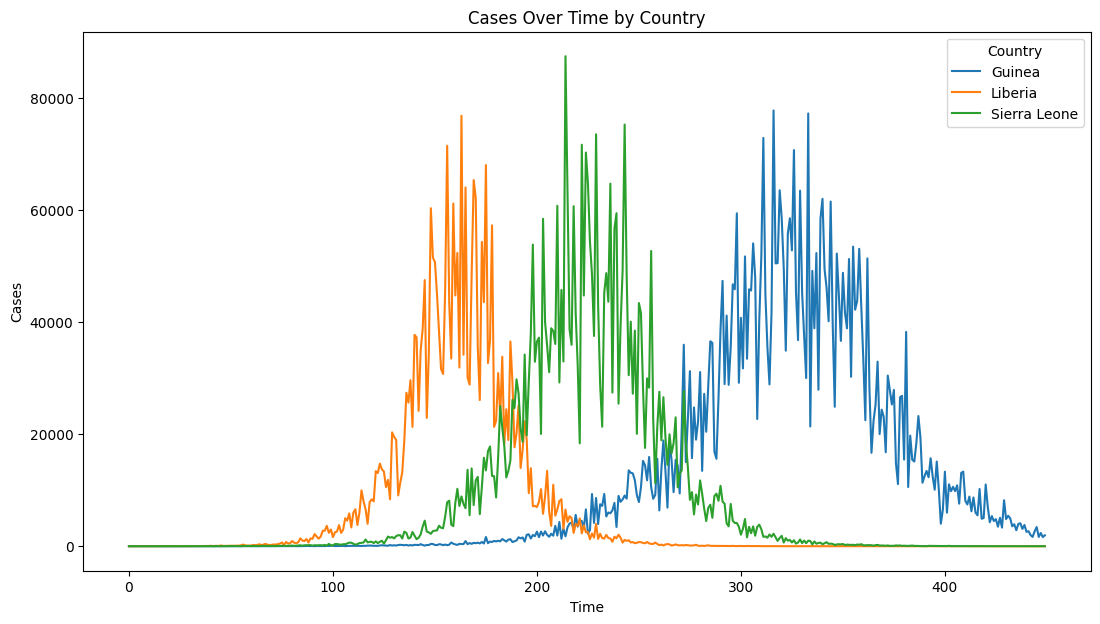

In [9]:
# Group the data by 'country' and plot each group
plt.figure(figsize=(13, 7))
for country, group in df.groupby('country'):
    plt.plot(group['time'], group['cases'], label=country)

# Add labels and legend
plt.xlabel('Time')
plt.ylabel('Cases')
plt.title('Cases Over Time by Country')
plt.legend(title='Country')
plt.show()

In [10]:
# Convert the 'time' column to datetime format, assuming it represents days since 2014-01-01
df["time"] = pd.Timestamp("2014-01-01") + pd.to_timedelta(df["time"], unit="D")

In [11]:
## get patches
patch_names = ["Guinea", "Liberia", "Sierra Leone"]
n_patches = len(patch_names)

# Set the start date to January 1, 2014
start_date =  df["time"].min()
# Calculate the end date from the maximum value in the 'time' column
end_date = df["time"].max()
weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
T = len(weeks)

# Create an empty array to store observed cases
I_obs = np.zeros((T, n_patches))
# country_data = df.copy()

# Fill the observed cases array with weekly data for each patch
for i, country in enumerate(patch_names):
    country_data = df[df["country"] == country]
    # Convert the 'time' column to datetime format
    # country_data["time"] = pd.to_datetime(country_data["time"], unit="D")  # Assuming 'time' is in days
    weekly_cases = country_data.groupby(pd.Grouper(key="time", freq="W-MON"))['cases'].sum()
    # weekly_cases.index = pd.to_datetime(weekly_cases.index)
    weekly_cases = weekly_cases.reindex(weeks, fill_value=0)
    I_obs[:, i] = weekly_cases.values

# Create a DataFrame for plotting
time = np.arange(1, T + 1)
data_plot = pd.DataFrame(I_obs, columns=patch_names)
data_plot["Time"] = time
data_plot["Week"] = weeks[:].strftime("%Y-%m-%d")
# Melt the DataFrame for easier plotting
data_plot = data_plot.melt(id_vars=["Time", "Week"], var_name="Patches", value_name="Cases")

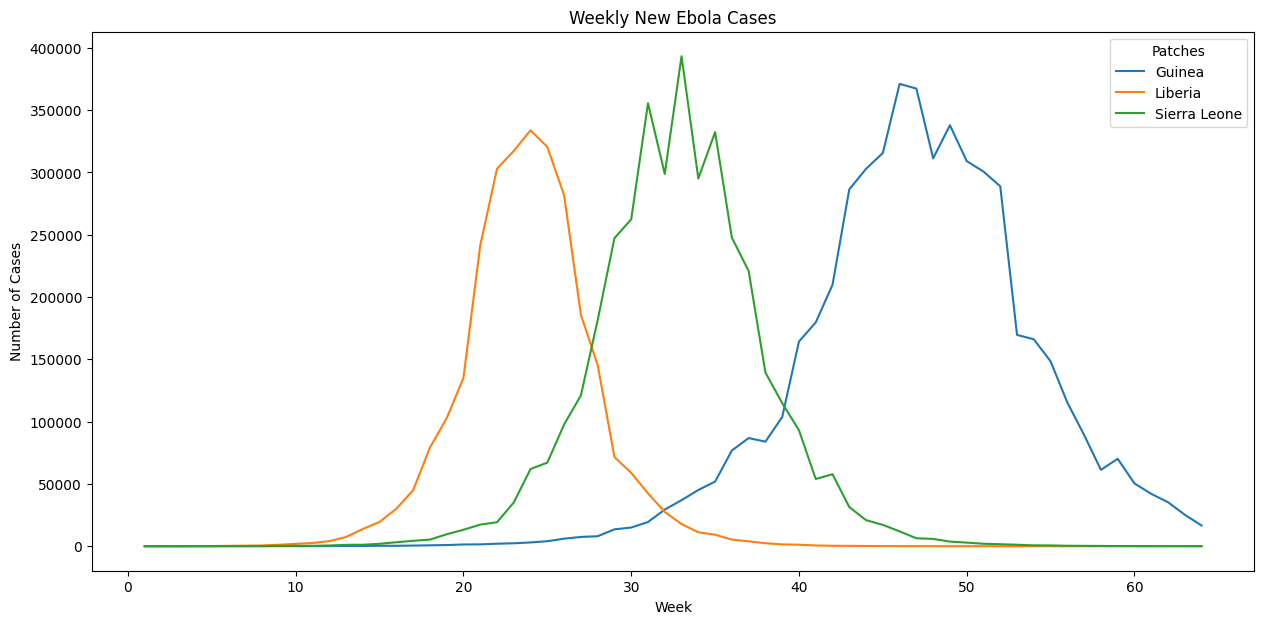

In [12]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=data_plot, x="Time", y="Cases", hue="Patches")
plt.title("Weekly New Ebola Cases")
plt.xlabel("Week")
plt.ylabel("Number of Cases")
# plt.grid(True)
plt.savefig('./images/weekly_cases.pdf', bbox_inches='tight')
plt.show()

In [13]:
# Population sizes (approximate, in millions)
n = np.array([11.5e6, 4.5e6, 6.8e6])  # Guinea, Liberia, Sierra Leone

N = np.sum(n)  # Total population

In [22]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases = weekly_cases.reindex(columns=countries, fill_value=0)
cases = weekly_cases.values  # Shape: (T, 3)

data = {
    'P': 3,
    'T': len(cases),
    't0': 0,
    'ts': np.arange(len(cases)),
    'cases': cases,
    'N': [11500000, 4500000, 6800000],
    # 'N': [30000, 500000, 25000]  # Effective population
    'E0': [1, 1, 1],
    'I0': [10, 20, 10]
}

print("Cases shape:", cases.shape)
print("Cases shape:", data_plot.shape)
print("\nFirst few weeks:\n", cases)

Cases shape: (65, 3)
Cases shape: (192, 4)

First few weeks:
 [[    17     21      5]
 [    16     41     15]
 [    11     40     22]
 [    24    109     30]
 [    20    129     28]
 [    36    256     66]
 [    33    463     69]
 [    38    555    135]
 [    56   1064    222]
 [    76   1911    339]
 [   104   2157    315]
 [   157   4224    577]
 [   211   6545   1001]
 [   203  12441   1142]
 [   349  18517   1850]
 [   344  27857   3077]
 [   469  46966   4116]
 [   681  69429   5016]
 [   985  97550   8789]
 [  1330 124494  13467]
 [  1597 223636  14334]
 [  1764 312086  20158]
 [  2271 294645  35205]
 [  3104 364898  51940]
 [  3628 296345  70211]
 [  5968 313596  99594]
 [  7050 171684 114377]
 [  8446 159703 162617]
 [ 12761  85948 244274]
 [ 14745  55884 261231]
 [ 17936  49074 330383]
 [ 28296  29605 290849]
 [ 32851  16119 391474]
 [ 47871  13781 303994]
 [ 48667   9510 321865]
 [ 78004   5710 279545]
 [ 86240   4250 241585]
 [ 85505   2410 147613]
 [ 89528   1683 115870]
 [

In [487]:
# Compile and fit the model
model_synth = CmdStanModel(stan_file="multi_patch.stan")
fit_synth = model_synth.sample(
    data=data,
    chains=4,
    iter_warmup= 500,
    iter_sampling=1000,
    seed=12
)
# Convert to ArviZ InferenceData for analysis
inference_data = az.from_cmdstanpy(fit_synth)

20:47:34 - cmdstanpy - INFO - compiling stan file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch.stan to exe file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch
INFO:cmdstanpy:compiling stan file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch.stan to exe file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch
20:47:46 - cmdstanpy - INFO - compiled model executable: /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch
INFO:cmdstanpy:compiled model executable: /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch
20:47:46 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status

























chain 1 |▌         | 04:42 Status















chain 1 |█▏        | 06:45 Iteration:    1 / 1500 [  0%]  (Warmup)


chain 


20:58:39 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
20:58:39 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_lpmf: Location parameter[28] is -1.88802e-08, but must be positive finite! (in 'multi_patch.stan', line 101, column 4 to column 55)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode

In [488]:
print(fit_synth.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [489]:
fit_synth.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-1750.180000,0.064525,2.280270,2.090470,-1754.340000,-1749.840000,-1747.100000,1322.04,1768.96,1.002700
sigma,0.457564,0.000486,0.016952,0.016155,0.432320,0.456244,0.487147,1293.35,1654.03,1.002380
gamma,0.109684,0.000189,0.007566,0.007404,0.097759,0.109467,0.122822,1613.17,2114.84,1.003090
beta[1],0.694882,0.000602,0.019106,0.018587,0.663472,0.695025,0.726264,1022.05,1229.44,1.003960
beta[2],1.447550,0.001803,0.057453,0.057414,1.350540,1.448410,1.539090,1041.97,1280.28,1.003290
...,...,...,...,...,...,...,...,...,...,...
"predicted_cases[64,2]",0.295500,0.008930,0.565031,0.000000,0.000000,0.000000,1.000000,4023.10,4063.68,0.999555
"predicted_cases[64,3]",48.717000,0.378641,23.087300,20.756400,18.000000,45.000000,91.000000,3822.81,3838.09,1.001790
"predicted_cases[65,1]",12186.700000,87.203300,5555.410000,5115.710000,5004.200000,11213.000000,22498.200000,4138.03,3722.42,1.000630
"predicted_cases[65,2]",0.236000,0.007868,0.499366,0.000000,0.000000,0.000000,1.000000,4024.99,3991.25,0.999885


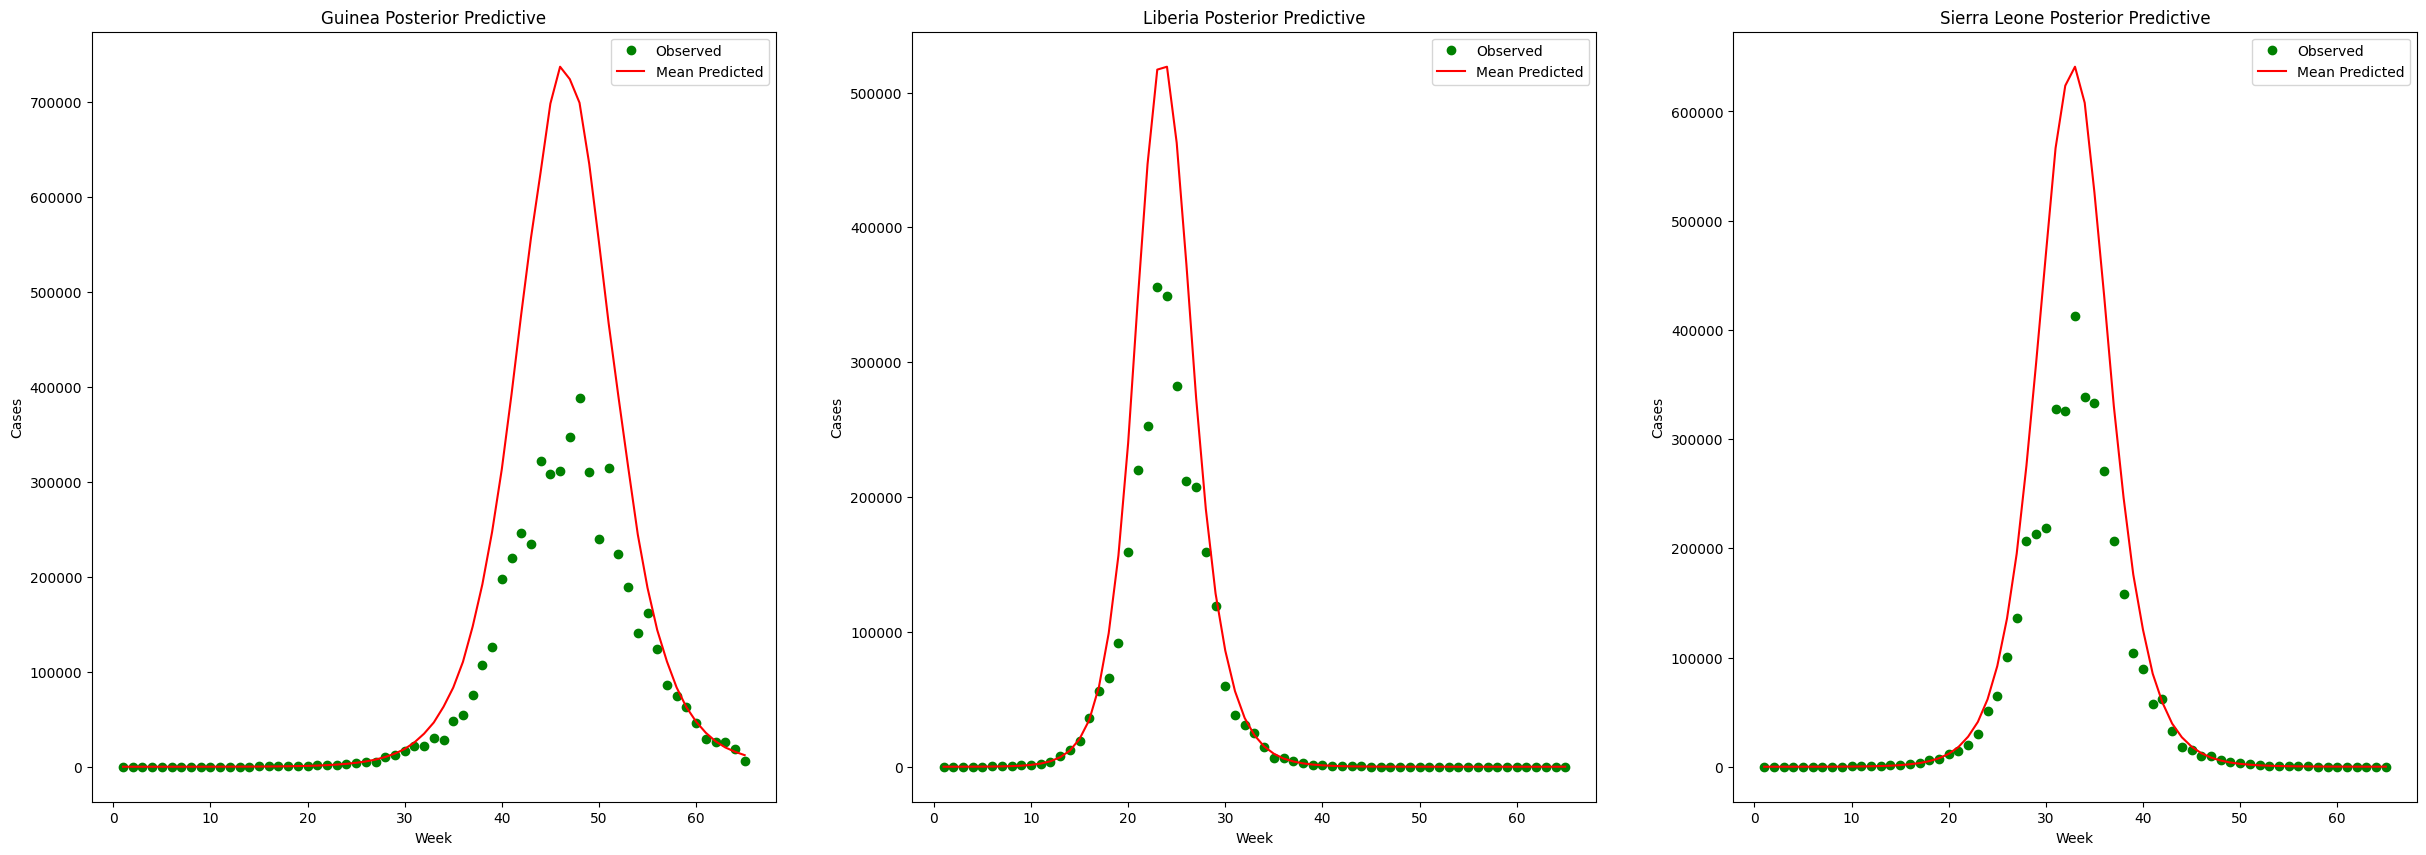

In [499]:
import matplotlib.pyplot as plt
predicted_cases = fit_synth.stan_variable('predicted_cases')  # Shape: (samples, T, P)

## subplot (1,3)
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
for p, country in enumerate(countries):
    # for i in range(400):
    #     plt.plot(data['ts'], predicted_cases[i, :, p], alpha=0.1, color='blue')
    axes[p].plot(data['ts'], data['cases'][:, p], 'o', label='Observed', color='green')
    axes[p].plot(data['ts'], predicted_cases.mean(axis=0)[:, p], label='Mean Predicted', color='red')
    axes[p].set_title(f'{country} Posterior Predictive')
    axes[p].set_xlabel('Week')
    axes[p].set_ylabel('Cases')
    axes[p].legend()
plt.show()

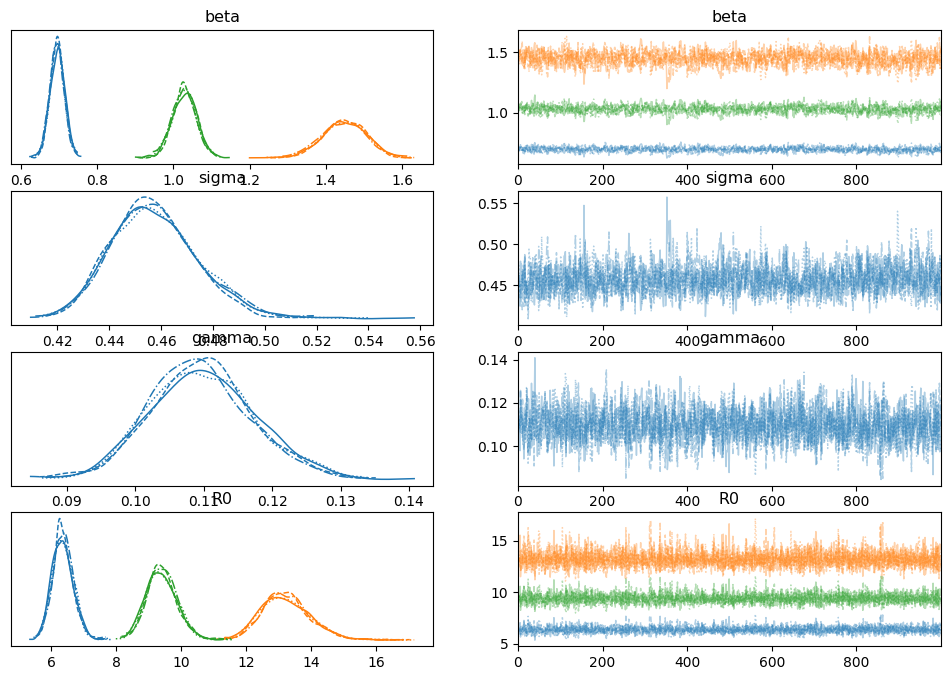

In [491]:
## trace plots
az.plot_trace(fit_synth, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

# Posterior Predictive Checks

KeyError: 'y_pred_p[1,1]'

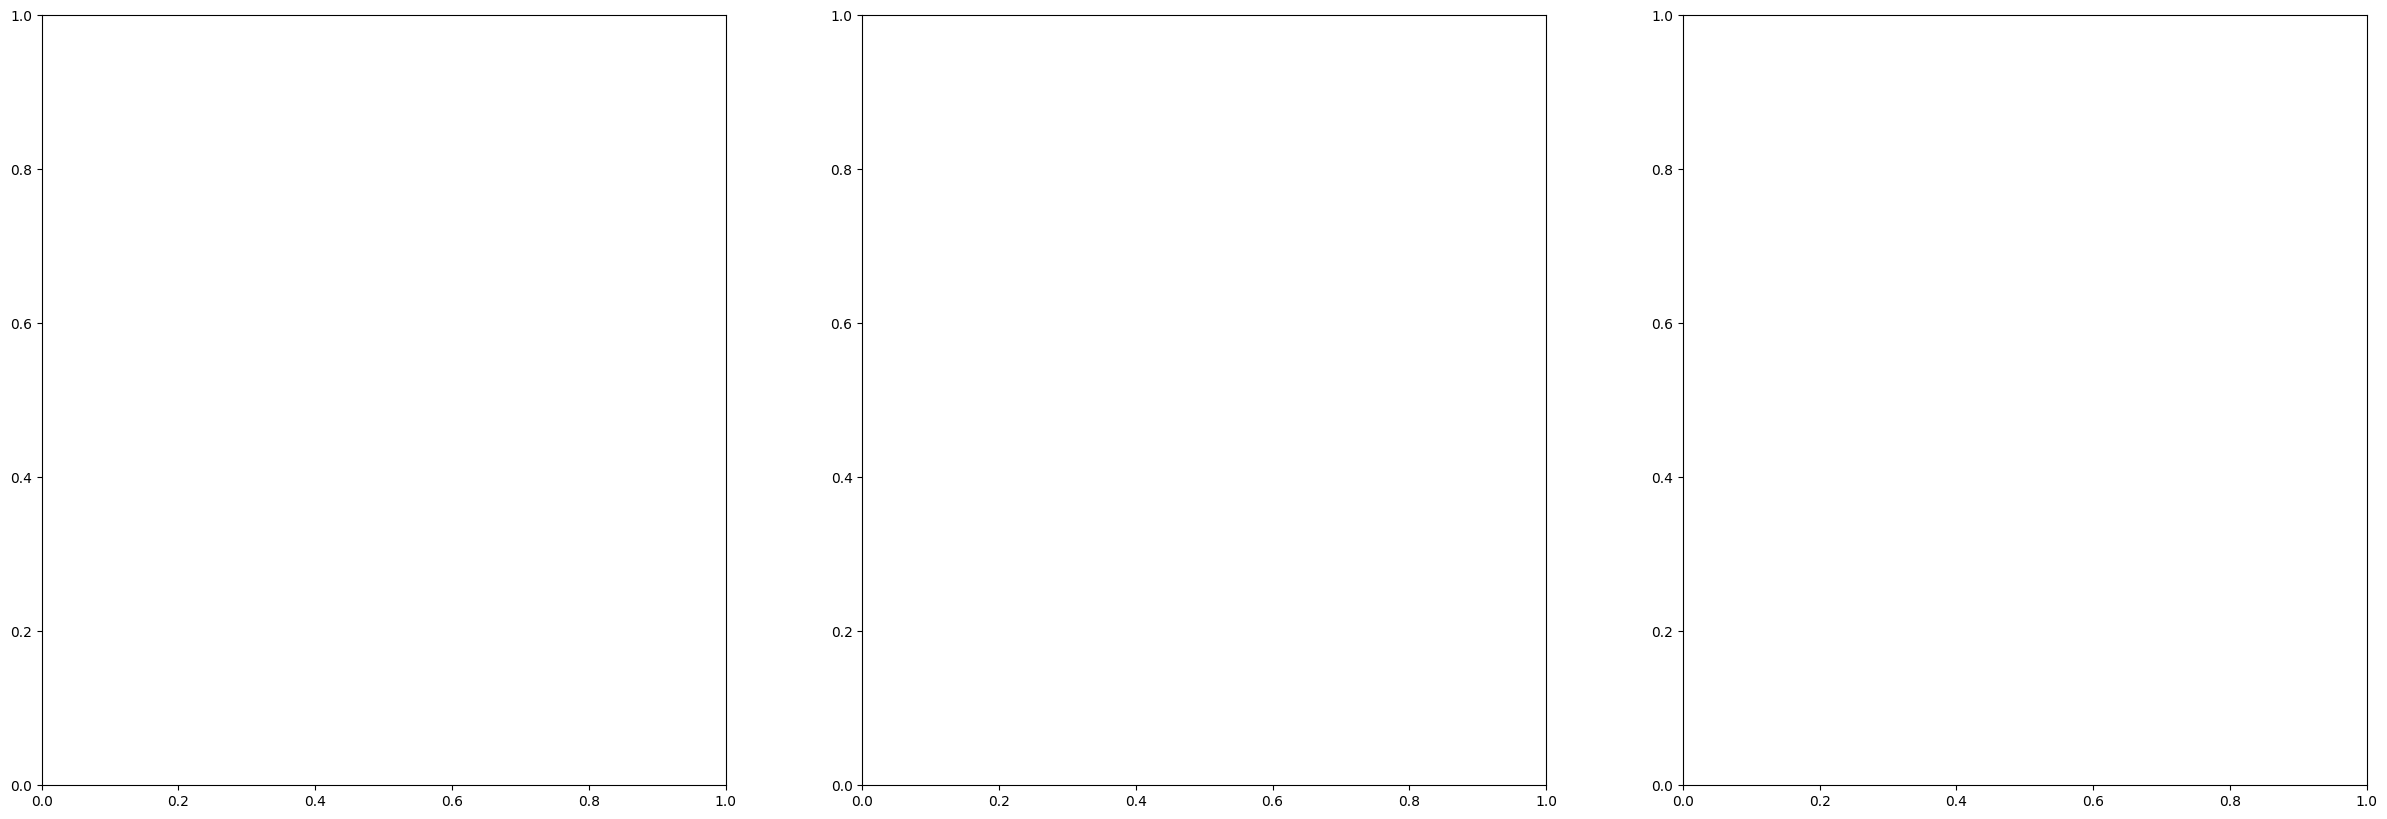

In [492]:

S = np.zeros(T)
E = np.zeros(T)
I = np.zeros(T)
R = np.zeros(T)

posterior_patch = fit_synth.draws_pd()
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
for p, country in enumerate(countries):
    for t in range(T):
        S[t] = posterior_patch[f'y_pred_p[{t+1},1]'].mean()
        E[t] = posterior_patch[f'y_pred_p[{t+1},2]'].mean()
        I[t] = posterior_patch[f'y_pred_p[{t+1},3]'].mean()
        R[t] = posterior_patch[f'y_pred_p[{t+1},4]'].mean()

    # Normalize fitted results
    S_frac = S / N
    E_frac = E / N
    I_frac = I / N
    R_frac = R / N

    # Fitted
    axes[p].plot(t, S_frac, label='Susceptible', color='blue')
    axes[p].plot(t, E_frac, label='Exposed', color='orange')
    axes[p].plot(t, I_frac, label='Infectious', color='red')
    axes[p].plot(t, R_frac, label='Recovered', color='green')

    plt.title('SEIR Model')
    plt.xlabel('Time (Weeks)')
    plt.ylabel('Population')
    plt.legend()
    # plt.grid(True)
plt.show()

In [494]:
p = fit_synth.summary()
p.filter(like="y_pred", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat


In [23]:
# Compile and fit the model
model_coupling = CmdStanModel(stan_file="patch_with_coupling.stan")
fit_coupling = model_coupling.sample(
    data=data,
    chains=4,
    iter_warmup= 500,
    iter_sampling=1000,
    seed=12
)
# Convert to ArviZ InferenceData for analysis
inference_data = az.from_cmdstanpy(fit_coupling)

20:45:13 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


20:45:13 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
20:45:13 - cmdstanpy - ERROR - Chain [3] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [3] error: error during processing Operation not permitted
20:45:13 - cmdstanpy - ERROR - Chain [2] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [2] error: error during processing Operation not permitted
20:45:13 - cmdstanpy - ERROR - Chain [4] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [4] error: error during processing Operation not permitted
chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00


20:45:13 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.


RuntimeError: Error during sampling:
Exception: ode_rk45: ode parameters and data[6] is nan, but must be finite! (in 'patch_with_coupling.stan', line 131, column 2 to line 139, column 4)
	Exception: ode_rk45: ode parameters and data[6] is nan, but must be finite! (in 'patch_with_coupling.stan', line 131, column 2 to line 139, column 4)
	Exception: ode_rk45: ode parameters and data[6] is nan, but must be finite! (in 'patch_with_coupling.stan', line 131, column 2 to line 139, column 4)
	Exception: ode_rk45: ode parameters and data[6] is nan, but must be finite! (in 'patch_with_coupling.stan', line 131, column 2 to line 139, column 4)
	Exception: ode_rk45: ode parameters and data[6] is nan, but must be finite! (in 'patch_with_coupling.stan', line 131, column 2 to line 139, column 4)
	Exception: ode_rk45: ode parameters and data[6] is nan, but must be finite! (in 'patch_with_coupling.stan', line 131, column 2 to line 139, column 4)
	Exception: ode_rk45: ode parameters and data[6] is nan, b